# Feature Engineering

### Age değişkeninin kategorik hale getirilmesi

In [74]:
data = df.copy()

In [75]:
data = data.drop(columns=['Tenure','HasCrCard','Complain'])

In [76]:
data.Age.value_counts()

Age
37    478
38    477
35    474
36    456
34    447
     ... 
92      2
82      1
88      1
85      1
83      1
Name: count, Length: 70, dtype: int64

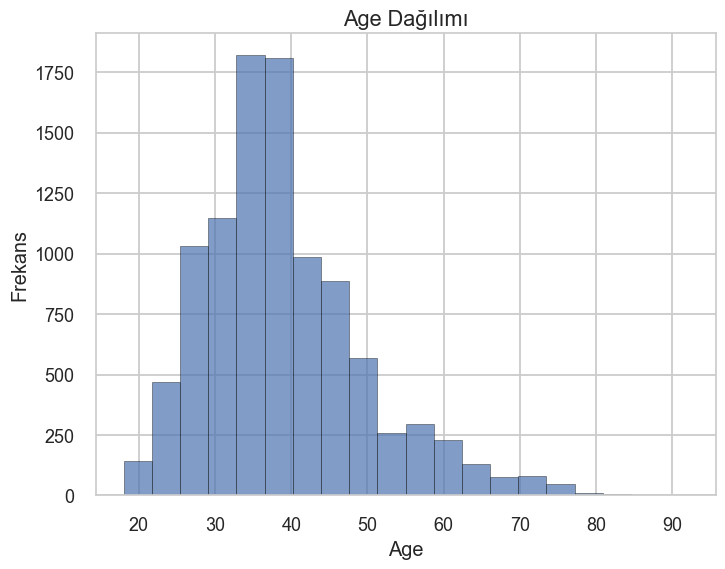

In [77]:
import matplotlib.pyplot as plt

# Age değişkeninin dağılımını görmek için histogram
def plot_age_distribution(df, age_col='Age'):
    plt.figure(figsize=(8, 6))
    plt.hist(df[age_col], bins=20, edgecolor='black', alpha=0.7)
    plt.title(f'{age_col} Dağılımı')
    plt.xlabel(age_col)
    plt.ylabel('Frekans')
    plt.grid(True)
    plt.show()

# Örnek kullanım
plot_age_distribution(data, 'Age')


In [78]:
data_1 = data.copy()

In [79]:
# Yaş grupları için sınırlar ve etiketler tanımlayalım
bins = [17, 29, 49, 64, float('inf')] # Sınırlar (17 dahil değil, 29 dahil)
labels = [0, 1, 2, 3] # Atanacak sayısal etiketler

# 'Age' sütununu kullanarak yeni bir 'Age_Group_Label' sütunu oluşturalım
data['Age_Group_Label'] = pd.cut(data['Age'], bins=bins, labels=labels, right=True)

In [80]:
data = data.drop(columns=['Age'])

In [81]:
data.head()

,CreditScore,Geography,Gender,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited,Satisfaction_Score,Card_Type,Point_Earned,Age_Group_Label
0,619,France,Female,0.00,1,1,101348.88,1,2,DIAMOND,464,1
1,608,Spain,Female,83807.86,1,1,112542.58,0,3,DIAMOND,456,1
2,502,France,Female,159660.80,3,0,113931.57,1,3,DIAMOND,377,1
3,699,France,Female,0.00,2,0,93826.63,0,5,GOLD,350,1
4,850,Spain,Female,125510.82,1,1,79084.10,0,5,GOLD,425,1


In [82]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

def encode_categorical_columns(df):
    le = LabelEncoder()
    categorical_cols = df.select_dtypes(include=['object']).columns  # Sayısal olmayan sütunları seç
    
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col])  # Label encoding işlemi
    
    return df

In [83]:
encode_categorical_columns(data)

,CreditScore,Geography,Gender,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited,Satisfaction_Score,Card_Type,Point_Earned,Age_Group_Label
0,619,0,0,0.00,1,1,101348.88,1,2,0,464,1
1,608,2,0,83807.86,1,1,112542.58,0,3,0,456,1
2,502,0,0,159660.80,3,0,113931.57,1,3,0,377,1
3,699,0,0,0.00,2,0,93826.63,0,5,1,350,1
4,850,2,0,125510.82,1,1,79084.10,0,5,1,425,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,0.00,2,0,96270.64,0,1,0,300,1
9996,516,0,1,57369.61,1,1,101699.77,0,5,2,771,1
9997,709,0,0,0.00,1,1,42085.58,1,3,3,564,1
9998,772,1,1,75075.31,2,0,92888.52,1,2,1,339,1


In [84]:
# Eğer 'Age_Group_Label' kategorikse, sayısal değerlere dönüştür
data['Age_Group_Label'] = data['Age_Group_Label'].cat.codes


In [85]:
encode_categorical_columns(data_1)

,CreditScore,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited,Satisfaction_Score,Card_Type,Point_Earned
0,619,0,0,42,0.00,1,1,101348.88,1,2,0,464
1,608,2,0,41,83807.86,1,1,112542.58,0,3,0,456
2,502,0,0,42,159660.80,3,0,113931.57,1,3,0,377
3,699,0,0,39,0.00,2,0,93826.63,0,5,1,350
4,850,2,0,43,125510.82,1,1,79084.10,0,5,1,425
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,0.00,2,0,96270.64,0,1,0,300
9996,516,0,1,35,57369.61,1,1,101699.77,0,5,2,771
9997,709,0,0,36,0.00,1,1,42085.58,1,3,3,564
9998,772,1,1,42,75075.31,2,0,92888.52,1,2,1,339


In [86]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb

def evaluate_model_accuracy(df, target_col='Exited'):
    # Veriyi ayır
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # Modeli eğit ve doğruluğu hesapla
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Doğruluk oranını döndür
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model doğruluğu: {accuracy:.4f}")

In [87]:
evaluate_model_accuracy(data_1, target_col='Exited')

Model doğruluğu: 0.8630


In [88]:
evaluate_model_accuracy(data, target_col='Exited')

Model doğruluğu: 0.8360


### LoyaltySegment

In [89]:
features_ = ['Tenure', 'NumOfProducts', 'IsActiveMember', 'Complain', 'Satisfaction_Score']

for col in features_:
    print(f"\n=== {col} için 'Exited' = 0 ===")
    print(df[df['Exited'] == 0][col].describe())
    
    print(f"\n=== {col} için 'Exited' = 1 ===")
    print(df[df['Exited'] == 1][col].describe())
    print("-" * 50)



=== Tenure için 'Exited' = 0 ===
count    7962.000000
mean        5.032781
std         2.880496
min         0.000000
25%         3.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: Tenure, dtype: float64

=== Tenure için 'Exited' = 1 ===
count    2038.000000
mean        4.934740
std         2.936768
min         0.000000
25%         2.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: Tenure, dtype: float64
--------------------------------------------------

=== NumOfProducts için 'Exited' = 0 ===
count    7962.000000
mean        1.544210
std         0.509542
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: NumOfProducts, dtype: float64

=== NumOfProducts için 'Exited' = 1 ===
count    2038.000000
mean        1.475466
std         0.801408
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: NumOfProducts, dtype: float

In [90]:
df21= df.copy()

In [91]:
def assign_loyalty_segment(row):
    score = 0

    # Tenure (Şirketteki süre)
    if row['Tenure'] >= 6:  # Daha uzun süreli müşteriler daha sadık olabilir.
        score += 2
    elif row['Tenure'] >= 3:
        score += 1

    # NumOfProducts (Ürün sayısı)
    if row['NumOfProducts'] >= 2:
        score += 2
    elif row['NumOfProducts'] == 1:
        score += 1

    # IsActiveMember (Aktif Üye Durumu)
    if row['IsActiveMember'] == 1:
        score += 2

    # Memnuniyet Skoru (Satisfaction_Score)
    if row['Satisfaction_Score'] >= 4:  # Yüksek memnuniyet daha fazla sadakat sağlar
        score += 2
    elif row['Satisfaction_Score'] == 3:
        score += 1

    # Şikayet Durumu (Complain)
    if row['Complain'] == 1:
        score -= 2  # Şikayet edenleri daha düşük sadakatle sınıflandır

    # Segment Atama
    if score >= 6:
        return 'High Loyalty'
    elif score >= 3:
        return 'Medium Loyalty'
    else:
        return 'Low Loyalty'


In [92]:
df21['LoyaltySegment'] = df21.apply(assign_loyalty_segment, axis=1)


In [93]:
encode_categorical_columns(df21)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned,LoyaltySegment
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456,1
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377,2
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350,2
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0,0,1,0,300,2
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0,0,5,2,771,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1,1,3,3,564,2
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1,1,2,1,339,1


In [94]:
df21[['LoyaltySegment', 'Complain']].corr()


,LoyaltySegment,Complain
LoyaltySegment,1.000000,0.082978
Complain,0.082978,1.000000


In [95]:
df21 = df21.drop(columns=['Complain'])

In [96]:
evaluate_model_accuracy(df21, target_col='Exited')

Model doğruluğu: 0.9365


In [97]:
train_and_evaluate_models(df21,'Exited')

C:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


                       Model  Train Score  Test Score  F1 Score
0              Random Forest     1.000000      0.9240  0.920322
1        Logistic Regression     0.804375      0.8085  0.764518
2  Artificial Neural Network     0.953375      0.9220  0.921462
3                        SVM     0.930875      0.9170  0.912088
4          Gradient Boosting     0.932250      0.9300  0.926973
5                    XGBoost     0.997875      0.9365  0.935010
6              Decision Tree     1.000000      0.9040  0.904000
7                        KNN     0.906875      0.8690  0.856254


,Model,Train Score,Test Score,F1 Score
0,Random Forest,1.000000,0.9240,0.920322
1,Logistic Regression,0.804375,0.8085,0.764518
2,Artificial Neural Network,0.953375,0.9220,0.921462
3,SVM,0.930875,0.9170,0.912088
4,Gradient Boosting,0.932250,0.9300,0.926973
5,XGBoost,0.997875,0.9365,0.935010
6,Decision Tree,1.000000,0.9040,0.904000
7,KNN,0.906875,0.8690,0.856254


Oluşturulan yeni değişken, model doğruluğunu anlamlı şekilde artırmıştır

### RiskSegment

In [98]:
df2 = df.copy()
df2['LoyaltySegment'] = df2.apply(assign_loyalty_segment, axis=1)
encode_categorical_columns(df2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned,LoyaltySegment
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456,1
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377,2
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350,2
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0,0,1,0,300,2
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0,0,5,2,771,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1,1,3,3,564,2
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1,1,2,1,339,1


In [99]:
features = ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'HasCrCard', 'Complain', 'Satisfaction_Score']

for col in features:
    print(f"\n=== {col} için 'Exited' = 0 ===")
    print(df2[df2['Exited'] == 0][col].describe())
    
    print(f"\n=== {col} için 'Exited' = 1 ===")
    print(df2[df2['Exited'] == 1][col].describe())
    print("-" * 50)



=== CreditScore için 'Exited' = 0 ===
count    7962.000000
mean      651.837855
std        95.650047
min       405.000000
25%       585.000000
50%       653.000000
75%       718.000000
max       850.000000
Name: CreditScore, dtype: float64

=== CreditScore için 'Exited' = 1 ===
count    2038.000000
mean      645.414622
std       100.337351
min       350.000000
25%       578.000000
50%       646.000000
75%       716.000000
max       850.000000
Name: CreditScore, dtype: float64
--------------------------------------------------

=== Age için 'Exited' = 0 ===
count    7962.000000
mean       37.408063
std        10.125957
min        18.000000
25%        31.000000
50%        36.000000
75%        41.000000
max        92.000000
Name: Age, dtype: float64

=== Age için 'Exited' = 1 ===
count    2038.000000
mean       44.835623
std         9.759754
min        18.000000
25%        38.000000
50%        45.000000
75%        51.000000
max        84.000000
Name: Age, dtype: float64
-----------------

In [100]:
df12 = df2.copy()

In [101]:
def assign_risk_segment(row):
    score = 0

    # CreditScore
    if row['CreditScore'] < 600:
        score += 2
    elif row['CreditScore'] < 650:
        score += 1

    # Age
    if row['Age'] > 50:
        score += 2
    elif row['Age'] > 40:
        score += 1

    # Balance
    if row['Balance'] < 30000:
        score += 2
    elif row['Balance'] < 100000:
        score += 1

    # Ürün sayısı
    if row['NumOfProducts'] == 1:
        score += 1
    elif row['NumOfProducts'] == 0:
        score += 2

    # Kredi kartı
    if row['HasCrCard'] == 0:
        score += 1

    # Şikayet ve memnuniyet
    if row['Complain'] == 1:
        score += 2
    elif row['Satisfaction_Score'] <= 2:
        score += 2
    elif row['Satisfaction_Score'] == 3:
        score += 1

    # Segment atama
    if score >= 7:
        return 'High Risk'
    elif score >= 4:
        return 'Medium Risk'
    else:
        return 'Low Risk'


In [102]:
df12['RiskSegment'] = df12.apply(assign_risk_segment, axis=1)

In [103]:
encode_categorical_columns(df12)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned,LoyaltySegment,RiskSegment
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464,1,0
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456,1,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377,2,2
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350,2,1
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0,0,1,0,300,2,2
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0,0,5,2,771,0,2
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1,1,3,3,564,2,2
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1,1,2,1,339,1,2


In [104]:
df12[['RiskSegment', 'Complain','Age', 'CreditScore','Balance', 'NumOfProducts','HasCrCard','Satisfaction_Score','LoyaltySegment','Exited']].corr()

,RiskSegment,Complain,Age,CreditScore,Balance,NumOfProducts,HasCrCard,Satisfaction_Score,LoyaltySegment,Exited
RiskSegment,1.000000,-0.061808,-0.058768,-0.017550,-0.021045,0.033091,0.007380,-0.116174,0.049631,-0.061271
Complain,-0.061808,1.000000,0.283530,-0.027048,0.119124,-0.046357,-0.007095,-0.004799,0.082978,0.995693
Age,-0.058768,0.283530,1.000000,-0.003965,0.028308,-0.030680,-0.011721,-0.000876,-0.036060,0.285296
CreditScore,-0.017550,-0.027048,-0.003965,1.000000,0.006268,0.012238,-0.005458,-0.012599,0.000872,-0.026771
Balance,-0.021045,0.119124,0.028308,0.006268,1.000000,-0.304180,-0.014858,-0.002588,0.109290,0.118577
NumOfProducts,0.033091,-0.046357,-0.030680,0.012238,-0.304180,1.000000,0.003183,-0.011394,-0.162014,-0.047611
HasCrCard,0.007380,-0.007095,-0.011721,-0.005458,-0.014858,0.003183,1.000000,-0.000212,-0.013461,-0.006976
Satisfaction_Score,-0.116174,-0.004799,-0.000876,-0.012599,-0.002588,-0.011394,-0.000212,1.000000,-0.259119,-0.005849
LoyaltySegment,0.049631,0.082978,-0.036060,0.000872,0.109290,-0.162014,-0.013461,-0.259119,1.000000,0.082920
Exited,-0.061271,0.995693,0.285296,-0.026771,0.118577,-0.047611,-0.006976,-0.005849,0.082920,1.000000


In [105]:
df12 = df12.drop(columns=['Complain'])

In [106]:
evaluate_model_accuracy(df12, target_col='Exited')

Model doğruluğu: 0.9520


In [107]:
train_and_evaluate_models(df12,'Exited')

C:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


                       Model  Train Score  Test Score  F1 Score
0              Random Forest     1.000000      0.9340  0.931558
1        Logistic Regression     0.806125      0.8105  0.766455
2  Artificial Neural Network     0.961375      0.9310  0.930593
3                        SVM     0.940375      0.9290  0.925748
4          Gradient Boosting     0.940875      0.9415  0.939927
5                    XGBoost     0.999625      0.9520  0.951472
6              Decision Tree     1.000000      0.9140  0.913579
7                        KNN     0.915375      0.8865  0.878568


,Model,Train Score,Test Score,F1 Score
0,Random Forest,1.000000,0.9340,0.931558
1,Logistic Regression,0.806125,0.8105,0.766455
2,Artificial Neural Network,0.961375,0.9310,0.930593
3,SVM,0.940375,0.9290,0.925748
4,Gradient Boosting,0.940875,0.9415,0.939927
5,XGBoost,0.999625,0.9520,0.951472
6,Decision Tree,1.000000,0.9140,0.913579
7,KNN,0.915375,0.8865,0.878568


### assign_engagement_level

In [108]:
features_2 = ['Balance', 'NumOfProducts', 'HasCrCard', 'Complain', 'IsActiveMember']

for col in features_2:
    print(f"\n=== {col} için 'Exited' = 0 ===")
    print(df2[df2['Exited'] == 0][col].describe())
    
    print(f"\n=== {col} için 'Exited' = 1 ===")
    print(df2[df2['Exited'] == 1][col].describe())
    print("-" * 50)



=== Balance için 'Exited' = 0 ===
count      7962.000000
mean      72742.750663
std       62851.577108
min           0.000000
25%           0.000000
50%       92063.060000
75%      126419.330000
max      221532.800000
Name: Balance, dtype: float64

=== Balance için 'Exited' = 1 ===
count      2038.000000
mean      91109.476006
std       58346.483197
min           0.000000
25%       38591.222500
50%      109344.230000
75%      131423.637500
max      250898.090000
Name: Balance, dtype: float64
--------------------------------------------------

=== NumOfProducts için 'Exited' = 0 ===
count    7962.000000
mean        1.544210
std         0.509542
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: NumOfProducts, dtype: float64

=== NumOfProducts için 'Exited' = 1 ===
count    2038.000000
mean        1.475466
std         0.801408
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.0000

In [109]:
df14 = df2.copy()

In [110]:
def assign_engagement_level(row):
    score = 0

    # Aktif Üye Kontrolü
    if row['IsActiveMember'] == 1:
        score += 2

    # Ürün Sayısı
    if row['NumOfProducts'] >= 2:
        score += 2
    elif row['NumOfProducts'] == 1:
        score += 1
    elif row['NumOfProducts'] == 0:
        score += 0  # 0 ürün, düşük etkileşim

    # Kredi Kartı Var mı?
    if row['HasCrCard'] == 1:
        score += 1

    # Bakiye
    if row['Balance'] > 100000:
        score += 2
    elif row['Balance'] > 50000:
        score += 1
    elif row['Balance'] > 10000:
        score += 0  # Düşük bakiye, düşük etkileşim

    # Şikayet
    if row['Complain'] == 1:
        score -= 1  # Şikayet, etkileşimi düşürür

    # Etkileşim seviyesini belirle
    if score >= 6:
        return 'High Engagement'
    elif score >= 3:
        return 'Medium Engagement'
    else:
        return 'Low Engagement'


In [111]:
df14['EngagementLevel'] = df14.apply(assign_engagement_level, axis=1)

In [112]:
df14['RiskSegment'] = df14.apply(assign_risk_segment, axis=1)

In [113]:
encode_categorical_columns(df14)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned,LoyaltySegment,EngagementLevel,RiskSegment
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464,1,2,0
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456,1,2,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377,2,2,2
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350,2,1,1
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0,0,1,0,300,2,2,2
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0,0,5,2,771,0,2,2
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1,1,3,3,564,2,1,2
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1,1,2,1,339,1,2,2


In [114]:
df14[['EngagementLevel','RiskSegment', 'Complain','IsActiveMember', 'Balance','HasCrCard', 'NumOfProducts','LoyaltySegment','Exited']].corr()

,EngagementLevel,RiskSegment,Complain,IsActiveMember,Balance,HasCrCard,NumOfProducts,LoyaltySegment,Exited
EngagementLevel,1.000000,0.124949,0.047901,-0.287025,-0.259500,-0.069497,0.026286,0.122470,0.047935
RiskSegment,0.124949,1.000000,-0.061808,0.001931,-0.021045,0.007380,0.033091,0.049631,-0.061271
Complain,0.047901,-0.061808,1.000000,-0.154741,0.119124,-0.007095,-0.046357,0.082978,0.995693
IsActiveMember,-0.287025,0.001931,-0.154741,1.000000,-0.010084,-0.011866,0.009612,-0.310712,-0.156356
Balance,-0.259500,-0.021045,0.119124,-0.010084,1.000000,-0.014858,-0.304180,0.109290,0.118577
HasCrCard,-0.069497,0.007380,-0.007095,-0.011866,-0.014858,1.000000,0.003183,-0.013461,-0.006976
NumOfProducts,0.026286,0.033091,-0.046357,0.009612,-0.304180,0.003183,1.000000,-0.162014,-0.047611
LoyaltySegment,0.122470,0.049631,0.082978,-0.310712,0.109290,-0.013461,-0.162014,1.000000,0.082920
Exited,0.047935,-0.061271,0.995693,-0.156356,0.118577,-0.006976,-0.047611,0.082920,1.000000


In [115]:
df14 = df14.drop(columns=['Complain'])

In [116]:
evaluate_model_accuracy(df14, target_col='Exited')

Model doğruluğu: 0.9640


In [117]:
train_and_evaluate_models(df14,'Exited')

C:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


                       Model  Train Score  Test Score  F1 Score
0              Random Forest     1.000000      0.9500  0.948855
1        Logistic Regression     0.805000      0.8105  0.766455
2  Artificial Neural Network     0.973500      0.9480  0.947641
3                        SVM     0.950625      0.9445  0.942548
4          Gradient Boosting     0.946500      0.9495  0.948372
5                    XGBoost     0.999750      0.9640  0.963566
6              Decision Tree     1.000000      0.9225  0.922537
7                        KNN     0.925375      0.8990  0.893439


,Model,Train Score,Test Score,F1 Score
0,Random Forest,1.000000,0.9500,0.948855
1,Logistic Regression,0.805000,0.8105,0.766455
2,Artificial Neural Network,0.973500,0.9480,0.947641
3,SVM,0.950625,0.9445,0.942548
4,Gradient Boosting,0.946500,0.9495,0.948372
5,XGBoost,0.999750,0.9640,0.963566
6,Decision Tree,1.000000,0.9225,0.922537
7,KNN,0.925375,0.8990,0.893439


### oluşturulan değişkenlerin görselleştirilmesi

#### LoyaltySegment Dağılımı

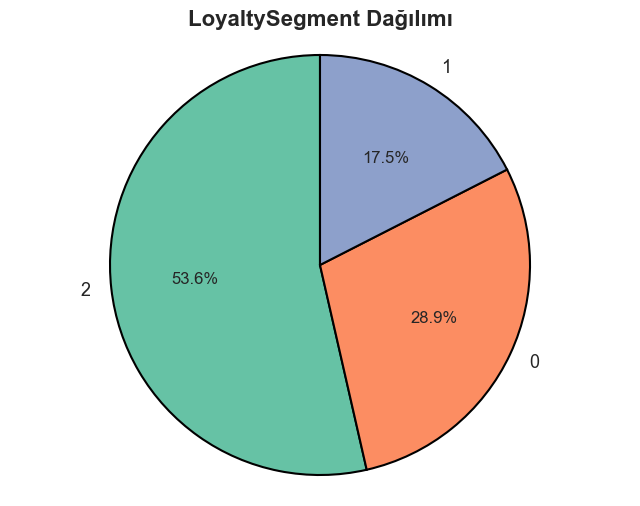

In [118]:
# Coğrafya verisinin frekanslarını al
LoyaltySegment = df14["LoyaltySegment"].value_counts()

# Pasta grafiği çiz
plt.figure(figsize=(8, 6))
plt.pie(LoyaltySegment, labels=LoyaltySegment.index, autopct="%1.1f%%", colors=plt.cm.Set2.colors, startangle=90, 
        wedgeprops={"edgecolor": "Black", "linewidth": 1.5, "linestyle": "solid"})
plt.title("LoyaltySegment Dağılımı", fontsize=16, weight="bold")
plt.axis("equal")  
plt.show()

In [119]:
df14["LoyaltySegment"].value_counts()

LoyaltySegment
2    5357
0    2894
1    1749
Name: count, dtype: int64

#### RiskSegment Dağılımı

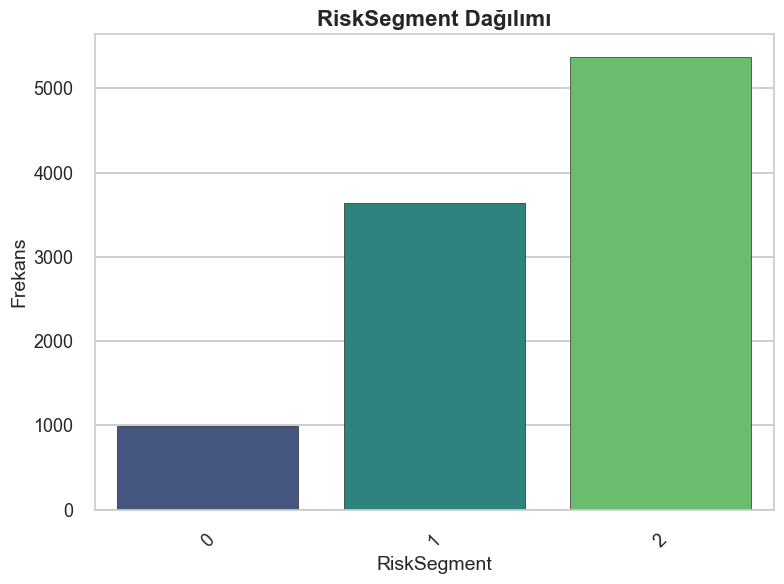

In [120]:
# Tenure değişkeninin frekanslarını al
plt.figure(figsize=(8, 6))
sns.countplot(x="RiskSegment", data=df14, palette="viridis", edgecolor="black")

# Başlık ve etiketleri ekle
plt.title("RiskSegment Dağılımı", fontsize=16, weight="bold")
plt.xlabel("RiskSegment", fontsize=14)
plt.ylabel("Frekans", fontsize=14)

plt.xticks(rotation=45)

# Görseli göster
plt.tight_layout()
plt.show()

In [121]:
df14["RiskSegment"].value_counts()

RiskSegment
2    5369
1    3637
0     994
Name: count, dtype: int64

#### assign_engagement_level Dağılımı

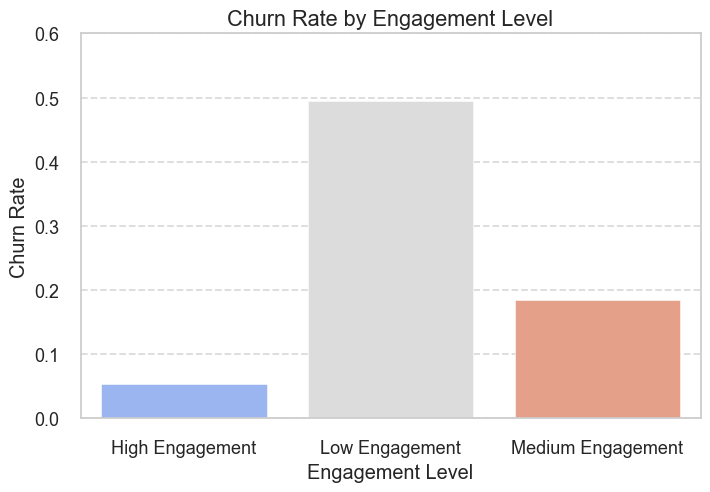

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

engagement_churn = df14.groupby('EngagementLevel')['Exited'].mean().reset_index()
engagement_churn['EngagementLabel'] = engagement_churn['EngagementLevel'].map({
    0: 'High Engagement',
    1: 'Low Engagement',
    2: 'Medium Engagement'
})

plt.figure(figsize=(8, 5))
sns.barplot(data=engagement_churn, x='EngagementLabel', y='Exited', palette='coolwarm')
plt.title('Churn Rate by Engagement Level')
plt.ylabel('Churn Rate')
plt.xlabel('Engagement Level')
plt.ylim(0, 0.6)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [123]:
df14.groupby('EngagementLevel')['Exited'].mean()


EngagementLevel
0    0.053879
1    0.495314
2    0.185141
Name: Exited, dtype: float64